#1. Pseudocódigo y diagrama de flujo para cada una de las siguientes tareas (a mano o con Mermaid, como en la sección 3):
   

In [ ]:
!apt-get -qq install gfortran
!gfortran --version

GNU Fortran (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
Copyright (C) 2023 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.




##a. Sacar el libro "Cien años de soledad" de la Biblioteca Central.




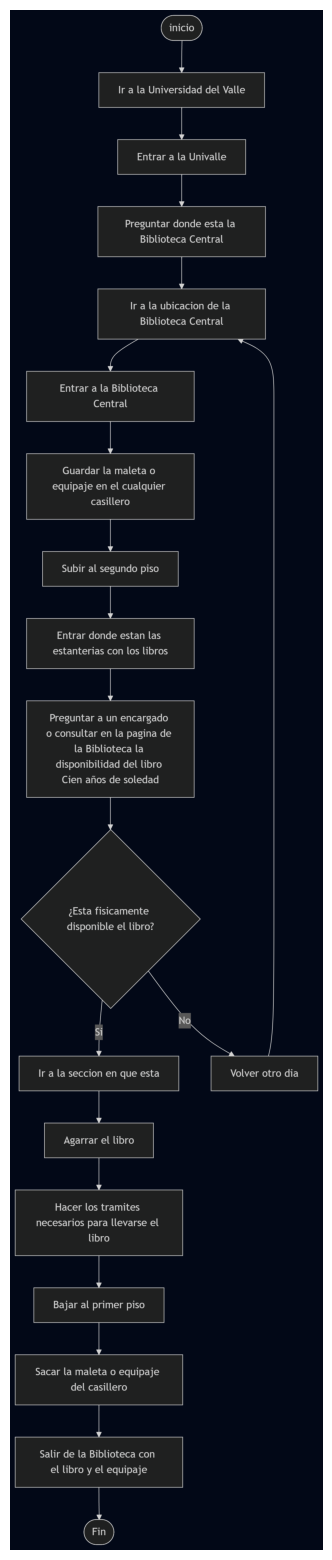

In [ ]:
# Importamos lo vamos a usar
from PIL import Image
import matplotlib.pyplot as plt
# Buscamos la imagen donde la guardamos
imagen = Image.open("sample_data/Diagramas de Flujo/mermaid-diagram-2026-09-12-182502.png")
# Mostramos la imagen
plt.figure(figsize=(20,20))
plt.imshow(imagen)
plt.axis("off")
plt.show()

## b. La receta para una tortilla.

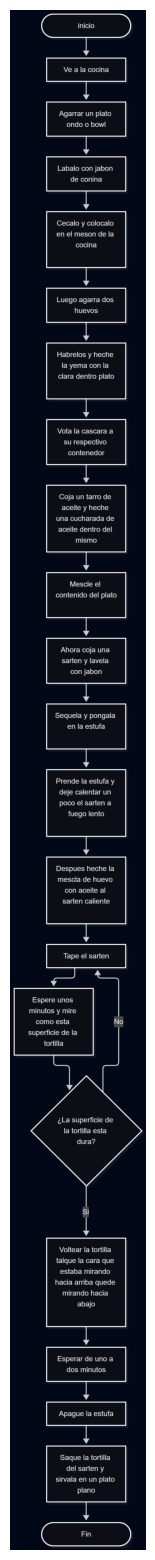

In [ ]:
# Importamos lo vamos a usar
from PIL import Image
import matplotlib.pyplot as plt
# Buscamos la imagen donde la guardamos
imagen = Image.open("sample_data/Diagramas de Flujo/mermaid-diagram-2026-09-14-203211.png")
# Mostramos la imagen
plt.figure(figsize=(20,20))
plt.imshow(imagen)
plt.axis("off")
plt.show()

##c. Almorzar en la Cafetería Central.

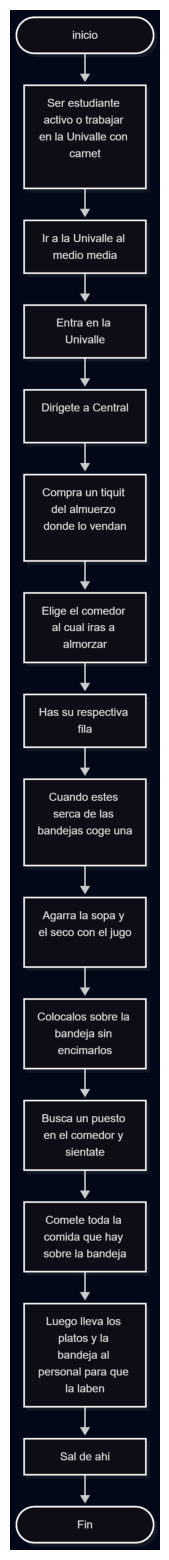

In [ ]:
# Importamos lo vamos a usar
from PIL import Image
import matplotlib.pyplot as plt
# Buscamos la imagen donde la guardamos
imagen = Image.open("sample_data/Diagramas de Flujo/mermaid-diagram-2026-09-14-211505.png")
# Mostramos la imagen
plt.figure(figsize=(20,20))
plt.imshow(imagen)
plt.axis("off")
plt.show()

##

#**2. Diseñe un programa en Fortran** que calcule la altura máxima de un proyectil, conociendo el ángulo respecto a la horizontal y la rapidez inicial. Siga el proceso completo de la sección 2 y el estilo del ejemplo integrador de la sección 9 (diagrama de flujo, diccionario de datos, constantes con `parameter`, eco de entradas). Su reporte debe contener el diagrama de flujo y/o pseudocodigo del programa que va a realizar.

   - Fórmula: $h_{max} = \dfrac{v_0^2 \sin^2(\theta)}{2g}$, con $g = 9.8\ m/s^2$.
   - Recuerde: `sin` espera el ángulo en radianes (sección 7) — convierta antes de usarlo.
   - Variables sugeridas: `v0`, `angulo_grados`, `angulo_rad`, `g`, `h_max` (todas `real`), y cuidado con no dividir enteros sin querer (sección 6).

**Celda de verificación:** al final del programa, agregue un bloque que compare `h_max` contra 2-3 casos de referencia conocidos e imprima `PASS`/`FAIL` para cada uno:

| Caso | `angulo_grados` | `v0` (m/s) | `h_max` esperado |
|---|---|---|---|
| 1 | 90° | 9.8 | 4.9000 m |
| 2 | 45° | 20.0 | 10.2041 m |
| 3 | 30° | 20.0 | 5.1020 m |

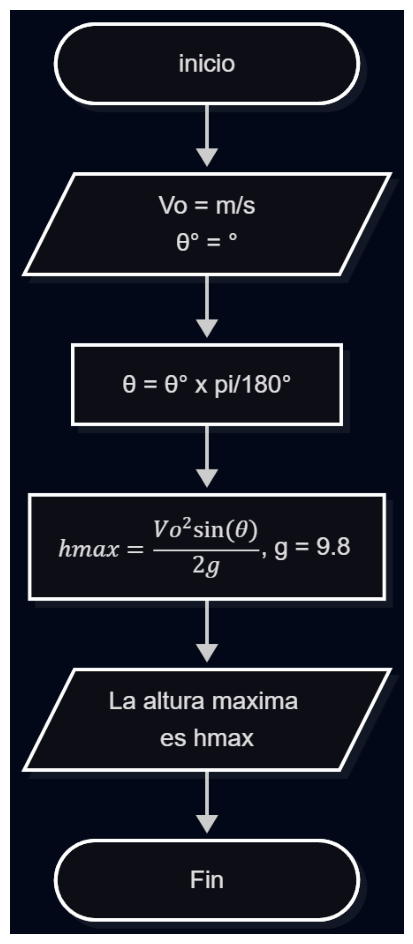

In [ ]:
# Importamos lo vamos a usar
from PIL import Image
import matplotlib.pyplot as plt
# Buscamos la imagen donde la guardamos
imagen = Image.open("sample_data/Diagramas de Flujo/mermaid-diagram-2026-09-16-203512.png")
# Mostramos la imagen
plt.figure(figsize=(12,12))
plt.imshow(imagen)
plt.axis("off")
plt.show()

In [2]:
%%writefile altura_maxima.f90
program altura_maxima ! Esto es el codigo base que voy a usar, pero lo voy a modificar para asi evaluar los casos de prueba.
    implicit none
    real :: Vo,Theta_grados,Theta_radianes,hmax ! Defino las variables que voy a usar

    real,parameter :: g=9.8 , pi=3.14159265

    print *, "Ingrese una velocidad inicial en m/s: " ! Aqui le pido al usuario que ingrese los datos que va a usar.
    read *, Vo

    print *, "Ingrese un ángulo en grados: "
    read *, Theta_grados

    Theta_radianes = Theta_grados*pi/180 ! Aqui lo convierto  los grados a radianes.

    hmax = (Vo**2*sin(Theta_radianes)**2)/(2*g) ! Aqui calculo la altura maxima.

    print *, "La altura máxima es: ",hmax ! Aqui muestro el resultado.

end program altura_maxima

Writing altura_maxima.f90


In [5]:
!gfortran altura_maxima.f90 -o altura_maxima
!./altura_maxima

 Ingrese una velocidad inicial en m/s: 
20
 Ingrese un ángulo en grados: 
30
 La altura máxima es:    5.10204077    


## Bloque de prueba del codigo en Fortran

### Caso 1: Vo = 9.8 m/s y Theta = 90°


In [13]:
%%writefile altura_maxima1.f90
program altura_maxima1
    implicit none
    real :: Vo,Theta_grados,Theta_radianes,hmax ! La diferencia de este con el base, es que en este no le pido los datos al usuario.
                                                ! Sino que los defino en el codigo para luego comparar el hmax calculado con el hmax conocido.
    real,parameter :: g=9.8 , pi=3.14159265     ! Y si la diferencia entre los mismos esta por debajo de una tolerancia que yo defino, entonces paso el caso de prueba.

     Vo=9.8
     Theta_grados=90

    Theta_radianes = Theta_grados*pi/180

    hmax = (Vo**2*sin(Theta_radianes)**2)/(2*g)

    if (abs(hmax- 4.9000) < 0.0001) then
      print *, "PASS"
    else
      print *, "FAIL"
    end if

end program altura_maxima1

Overwriting altura_maxima1.f90


In [15]:
!gfortran altura_maxima1.f90 -o altura_maxima1
!./altura_maxima1


 PASS


### Caso 2: Vo = 20.0 y Theta = 45°

In [16]:
%%writefile altura_maxima2.f90
program altura_maxima2
    implicit none
    real :: Vo,Theta_grados,Theta_radianes,hmax ! La diferencia de este con el base, es que en este no le pido los datos al usuario.
                                                ! Sino que los defino en el codigo para luego comparar el hmax calculado con el hmax conocido.
    real,parameter :: g=9.8 , pi=3.14159265     ! Y si la diferencia entre los mismos esta por debajo de una tolerancia que yo defino, entonces paso el caso de prueba.

     Vo=20.0
     Theta_grados=45

    Theta_radianes = Theta_grados*pi/180

    hmax = (Vo**2*sin(Theta_radianes)**2)/(2*g)

    if (abs(hmax- 10.2041) < 0.0001) then
      print *, "PASS"
    else
      print *, "FAIL"
    end if

end program altura_maxima2

Writing altura_maxima2.f90


In [17]:
!gfortran altura_maxima2.f90 -o altura_maxima2
!./altura_maxima2

 PASS


### Caso 3: Vo = 20 y theta = 30°

In [19]:
%%writefile altura_maxima3.f90
program altura_maxima3
    implicit none
    real :: Vo,Theta_grados,Theta_radianes,hmax ! La diferencia de este con el base, es que en este no le pido los datos al usuario.
                                                ! Sino que los defino en el codigo para luego comparar el hmax calculado con el hmax conocido.
    real,parameter :: g=9.8 , pi=3.14159265     ! Y si la diferencia entre los mismos esta por debajo de una tolerancia que yo defino, entonces paso el caso de prueba.

     Vo=20.0
     Theta_grados=30

    Theta_radianes = Theta_grados*pi/180

    hmax = (Vo**2*sin(Theta_radianes)**2)/(2*g)

    if (abs(hmax- 5.1020) < 0.0001) then
      print *, "PASS"
    else
      print *, "FAIL"
    end if

end program altura_maxima3

Overwriting altura_maxima3.f90


In [20]:
!gfortran altura_maxima3.f90 -o altura_maxima3
!./altura_maxima3

 PASS


#**3. Glosario:** defina con sus propias palabras: *algoritmo*, *variable*, *constante*, *tipo de dato*, *diagrama de flujo*, *pseudocódigo*, *entrada de datos*, *salida de datos*, `implicit none`, *diccionario de datos*, *división entera*, *función intrínseca*, *operador lógico*, *error de sintaxis*, *error de ejecución*, *error lógico*.

**Algoritmo:** Son los pasos odernados que  seguira el computador para resolver un problema.

**Variable:** es lo que almacena y manipula los datos.

**Constante:** Es una variable cuyos datos almacenados no cambian y no dependen de otras variables.

**Tipo de dato:** Es la clasificacion que se le da a los datos, y con eso el computador procesa esa informacion de acuerdo a como se le clasifico.

**Diagrama de flujo:** Son los pasos logicos que va a seguir un sierto programa, cuyos estan ordenados mediante figuras geometricas y flechas, facilitando la comprecion de esos pasos logicos.

**Pseudocodico:** Son los pasos que seguira un programa, el cual esta escrito en un lenguaje humano y de un estructura logica parecida a la de programacion.

**Entrada de datos:** Es en donde ingresa la informacion.

**Salida de datos:** Es lo que se muestra al final de un programa, es decir, el resultado obtenido al finalizar los pasos que se le dijo al computador que hiciera. Ya puede ser mientras las pantallas de los monitores o los altaboses, y otros dispositivos de salida.

**implicit none:** Es lo que le dice a Fortran que no declare las variables de madera autamatica, por lo que le tocaria al programador hacerlo a mano.

 **Diccionario de datos:** Es un compendio de instrucciones que se les da al computador para distintos tipos de lenguaje de programacion. Eso dificulta  iniciar desde cero en un lenguaje cuando ya venias de otro o tambien cuando regresas a un lenguaje que hace tiempo no practicabas.

 **Division entera:** Division entre dos numeros enteros cuyo resultado tambien pertenera a los numeros enteros.

 **Funsion intriseca:** Es una funcion que por defecto viene definida en lengujes de programacion que este usando.

 **Operador logico:** Es el que permite dar la orden al computador de que tome  deciciones y haga comparaciones.

 **Error de sintaxis:** Escribir mal alguna instruccion en el programa, haciendo que la ejecucion del mismo no sea posible.

 **Error de ejecucion:** Es cuando se ordena a la computadora hacer una operacion matematica invalida o no definida.

 **Error logico**: Es cuando  un programa realizado se ejecuta correctamente pero no da el resultado esperado o simplemente no soluciona correctamente el problema que deberia resolver.